<a href="https://colab.research.google.com/github/leman-cap13/Machine_Learning/blob/main/Linear_Algebra_in_ML_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Linear Algebra in Machine Learning & AI
## *Discovered Through One Word: "king"*

---

> **The Big Idea:** You're not here to study math.
> You're here to reverse-engineer how machines understand language.
> Linear algebra will appear — not because we introduce it, but because we *need* it.

---

###  What We'll Discover

| Part | Title | Concept Unlocked |
|------|-------|------------------|
| 1 | Words as Geometry | Vectors, Norm, Distance |
| 2 | Similarity as Angle | Dot Product, Cosine Similarity |
| 3 | Meaning as Direction | Projection, Semantic Arithmetic |
| 4 | How Embeddings Are Created | Matrix Multiplication |
| 5 | Neural Networks as Space Transformers | Linear Transformations |
| 6 | The Richness of Representation | Rank |
| 7 | Compression of Intelligence | Eigenvectors, PCA, SVD |

---

###  Setup — Install Everything First

In [1]:

!pip install numpy matplotlib scikit-learn --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'text.color': '#ccccee',
    'xtick.color': '#ccccee',
    'ytick.color': '#ccccee',
    'grid.color': '#333355',
    'grid.linestyle': '--',
    'font.family': 'monospace',
    'font.size': 11
})

print(' All dependencies loaded. Let\'s reverse-engineer AI.')

 All dependencies loaded. Let's reverse-engineer AI.


---

##  PART 1 — Words as Geometry
### *The moment a string becomes a vector*

---

**The question that starts everything:**

How does a computer understand that *king* and *queen* are related?
How does it know *king* is more similar to *queen* than to *banana*?

It can't. Not if a word is just a string or an ID like `532`.

With an ID:
```
king  → 532
queen → 891
man   → 104
```
|532 - 891| = 359   and   |532 - 104| = 428

These numbers mean **nothing**. There's no geometry. No closeness. No structure.

**The solution:** Give every word a location in space — a **vector**.

```python
king = [0.12, -0.98, 1.43, 0.57, -0.22, ...]  # 300 numbers
```

Now words have **positions**. Similar words live **near each other**.
And we can measure distance. That's geometry. That's power.

---

###  Concept: Norm (Length of a Vector)

The **norm** answers: *how long is this vector?*

$$\|\mathbf{v}\| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2}$$

Think of it as the word's "intensity" — how strongly it sits in semantic space.

###  Concept: Distance Between Vectors

$$\text{distance}(\mathbf{a}, \mathbf{b}) = \|\mathbf{a} - \mathbf{b}\|$$

Small distance → similar meaning. Large distance → different meaning.

In [27]:
words = {
    'king':   np.array([0.9,  0.7]),
    'queen':  np.array([0.85, -0.6]),
    'man':    np.array([0.1,  0.65]),
    'woman':  np.array([0.05, -0.7]),
    'prince': np.array([0.7,  0.5]),
    'banana': np.array([-1.2, 0.1]),
    'apple':  np.array([-1.1, -0.2]),
}

In [28]:
for word, vec in words.items():
    norm = np.linalg.norm(vec)
    print(f'  ||{word:6s}|| = {norm:.4f}')

  ||king  || = 1.1402
  ||queen || = 1.0404
  ||man   || = 0.6576
  ||woman || = 0.7018
  ||prince|| = 0.8602
  ||banana|| = 1.2042
  ||apple || = 1.1180


In [29]:
king_vec   = words['king']
queen_vec  = words['queen']
banana_vec = words['banana']

dist_kq = np.linalg.norm(king_vec - queen_vec)
dist_kb = np.linalg.norm(king_vec - banana_vec)

print('=== EUCLIDEAN DISTANCES ===')
print(f'  ||king − queen||  = {dist_kq:.4f}  ← small: semantically close')
print(f'  ||king − banana|| = {dist_kb:.4f}  ← large: semantically distant')
print(f'\n  Ratio: king-banana is {dist_kb/dist_kq:.1f}x farther than king-queen')

=== EUCLIDEAN DISTANCES ===
  ||king − queen||  = 1.3010  ← small: semantically close
  ||king − banana|| = 2.1840  ← large: semantically distant

  Ratio: king-banana is 1.7x farther than king-queen


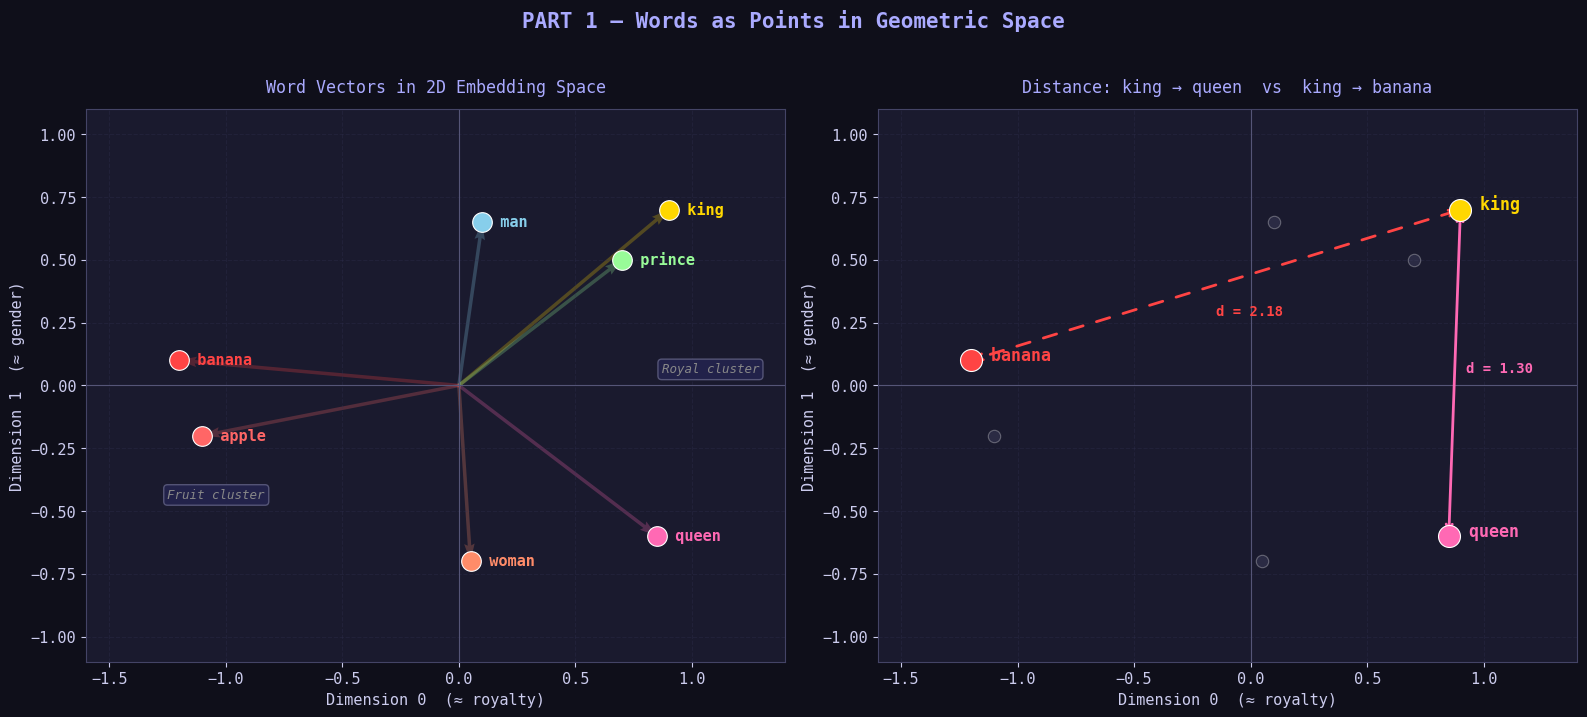


💡 Key insight: Words are POINTS. Meaning is DISTANCE.
   Linear algebra gives us the tools to measure that distance.


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('PART 1 — Words as Points in Geometric Space',
             fontsize=15, fontweight='bold', color='#aaaaff', y=1.02)

colors = {
    'king': '#FFD700', 'queen': '#FF69B4', 'man': '#87CEEB',
    'woman': '#FF8C69', 'prince': '#98FB98',
    'banana': '#FF4444', 'apple': '#FF6666'
}

ax = axes[0]
ax.set_title('Word Vectors in 2D Embedding Space', color='#aaaaff', fontsize=12, pad=12)

for word, vec in words.items():
    c = colors[word]
    ax.scatter(*vec, s=200, color=c, zorder=5, edgecolors='white', linewidths=0.8)
    ax.annotate(f'  {word}', vec, fontsize=11, color=c, fontweight='bold',
                va='center')
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1,
              color=c, alpha=0.25, width=0.005)

ax.axhline(0, color='#555577', linewidth=0.8)
ax.axvline(0, color='#555577', linewidth=0.8)
ax.set_xlabel('Dimension 0  (≈ royalty)')
ax.set_ylabel('Dimension 1  (≈ gender)')
ax.grid(True, alpha=0.3)
ax.set_xlim(-1.6, 1.4)
ax.set_ylim(-1.1, 1.1)


# Cluster annotations
ax.annotate('Royal cluster', xy=(0.87, 0.05), fontsize=9,
            color='#888888', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', fc='#22224a', ec='#555577'))
ax.annotate('Fruit cluster', xy=(-1.25, -0.45), fontsize=9,
            color='#888888', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', fc='#22224a', ec='#555577'))

# ── RIGHT PLOT: Distance comparison ───────────────────────────────────
ax2 = axes[1]
ax2.set_title('Distance: king → queen  vs  king → banana', color='#aaaaff', fontsize=12, pad=12)

highlight = {'king': '#FFD700', 'queen': '#FF69B4', 'banana': '#FF4444'}
for word, vec in words.items():
    c = highlight.get(word, '#555577')
    ax2.scatter(*vec, s=250 if word in highlight else 80,
                color=c, zorder=5, edgecolors='white', linewidths=0.8,
                alpha=1.0 if word in highlight else 0.3)
    if word in highlight:
        ax2.annotate(f'  {word}', vec, fontsize=12, color=c, fontweight='bold')

# Draw distance lines
k, q, b = words['king'], words['queen'], words['banana']
ax2.annotate('', xy=q, xytext=k,
             arrowprops=dict(arrowstyle='<->', color='#FF69B4', lw=2))
ax2.text((k[0]+q[0])/2 + 0.05, (k[1]+q[1])/2, f'd = {dist_kq:.2f}',
         color='#FF69B4', fontsize=10, fontweight='bold')

ax2.annotate('', xy=b, xytext=k,
             arrowprops=dict(arrowstyle='<->', color='#FF4444', lw=2, linestyle=(0, (5, 5))))
ax2.text((k[0]+b[0])/2, (k[1]+b[1])/2 - 0.12, f'd = {dist_kb:.2f}',
         color='#FF4444', fontsize=10, fontweight='bold')

ax2.axhline(0, color='#555577', linewidth=0.8)
ax2.axvline(0, color='#555577', linewidth=0.8)
ax2.set_xlabel('Dimension 0  (≈ royalty)')
ax2.set_ylabel('Dimension 1  (≈ gender)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-1.6, 1.4)
ax2.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.savefig('part1_words_as_geometry.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('\n💡 Key insight: Words are POINTS. Meaning is DISTANCE.')
print('   Linear algebra gives us the tools to measure that distance.')

---

##  PART 2 — Similarity as Angle
### *Why we measure alignment, not just distance*

---

Distance has a weakness. If I scale *king* to be twice as long, its distance to *queen* changes — but its **meaning** hasn't changed at all.

We need something better: **angle**.

Two vectors pointing in the same direction? → Same concept. Angle = 0°.
Two vectors at 90°? → Completely unrelated.
Two vectors pointing opposite? → Opposite meaning. Angle = 180°.

---

###  Concept: Dot Product

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i = a_1 b_1 + a_2 b_2 + \cdots + a_n b_n$$

Geometrically: $\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\| \|\mathbf{b}\| \cos(\theta)$

Large dot product → vectors point in similar directions → similar meaning.

###  Concept: Cosine Similarity

To isolate the angle (remove the effect of vector length):

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \|\mathbf{b}\|}$$

- Result = **1.0** → identical direction → same concept
- Result = **0.0** → perpendicular → no relationship
- Result = **-1.0** → opposite → antonyms

In [31]:
def dot_product(a, b):
    """Manual dot product — sum of element-wise products"""
    return sum(ai * bi for ai, bi in zip(a, b))

def cosine_similarity(a, b):
    """Cosine similarity = dot product / (norm_a * norm_b)"""
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def angle_degrees(a, b):
    cos_sim = np.clip(cosine_similarity(a, b), -1, 1)
    return np.degrees(np.arccos(cos_sim))

In [32]:
print('=== DOT PRODUCT: STEP BY STEP ===')
k, q = words['king'], words['queen']
print(f'  king  = {k}')
print(f'  queen = {q}')
print(f'  Element-wise products: {k[0]:.2f}×{q[0]:.2f}={k[0]*q[0]:.4f},  {k[1]:.2f}×{q[1]:.2f}={k[1]*q[1]:.4f}')
print(f'  Dot product = {np.dot(k, q):.4f}')

print()
print('=== COSINE SIMILARITY: ALL PAIRS WITH KING ===')
print(f'{"Word":<8}  {"Dot Product":>12}  {"Cosine Sim":>12}  {"Angle":>8}  Interpretation')
print('-' * 72)

=== DOT PRODUCT: STEP BY STEP ===
  king  = [0.9 0.7]
  queen = [ 0.85 -0.6 ]
  Element-wise products: 0.90×0.85=0.7650,  0.70×-0.60=-0.4200
  Dot product = 0.3450

=== COSINE SIMILARITY: ALL PAIRS WITH KING ===
Word       Dot Product    Cosine Sim     Angle  Interpretation
------------------------------------------------------------------------


In [33]:
interpretations = {
    'king':   '← identical (itself)',
    'queen':  '← very similar',
    'prince': '← similar (royalty)',
    'man':    '← somewhat related',
    'woman':  '← somewhat related',
    'banana': '← very different',
    'apple':  '← very different',
}

results = []
for word, vec in words.items():
    dp = np.dot(words['king'], vec)
    cs = cosine_similarity(words['king'], vec)
    angle = angle_degrees(words['king'], vec)
    interp = interpretations.get(word, '')
    results.append((word, dp, cs, angle))
    print(f'{word:<8}  {dp:>12.4f}  {cs:>12.4f}  {angle:>7.1f}°  {interp}')

king            1.3000        1.0000      0.0°  ← identical (itself)
queen           0.3450        0.2908     73.1°  ← very similar
man             0.5450        0.7268     43.4°  ← somewhat related
woman          -0.4450       -0.5561    123.8°  ← somewhat related
prince          0.9800        0.9992      2.3°  ← similar (royalty)
banana         -1.0100       -0.7356    137.4°  ← very different
apple          -1.1300       -0.8864    152.4°  ← very different


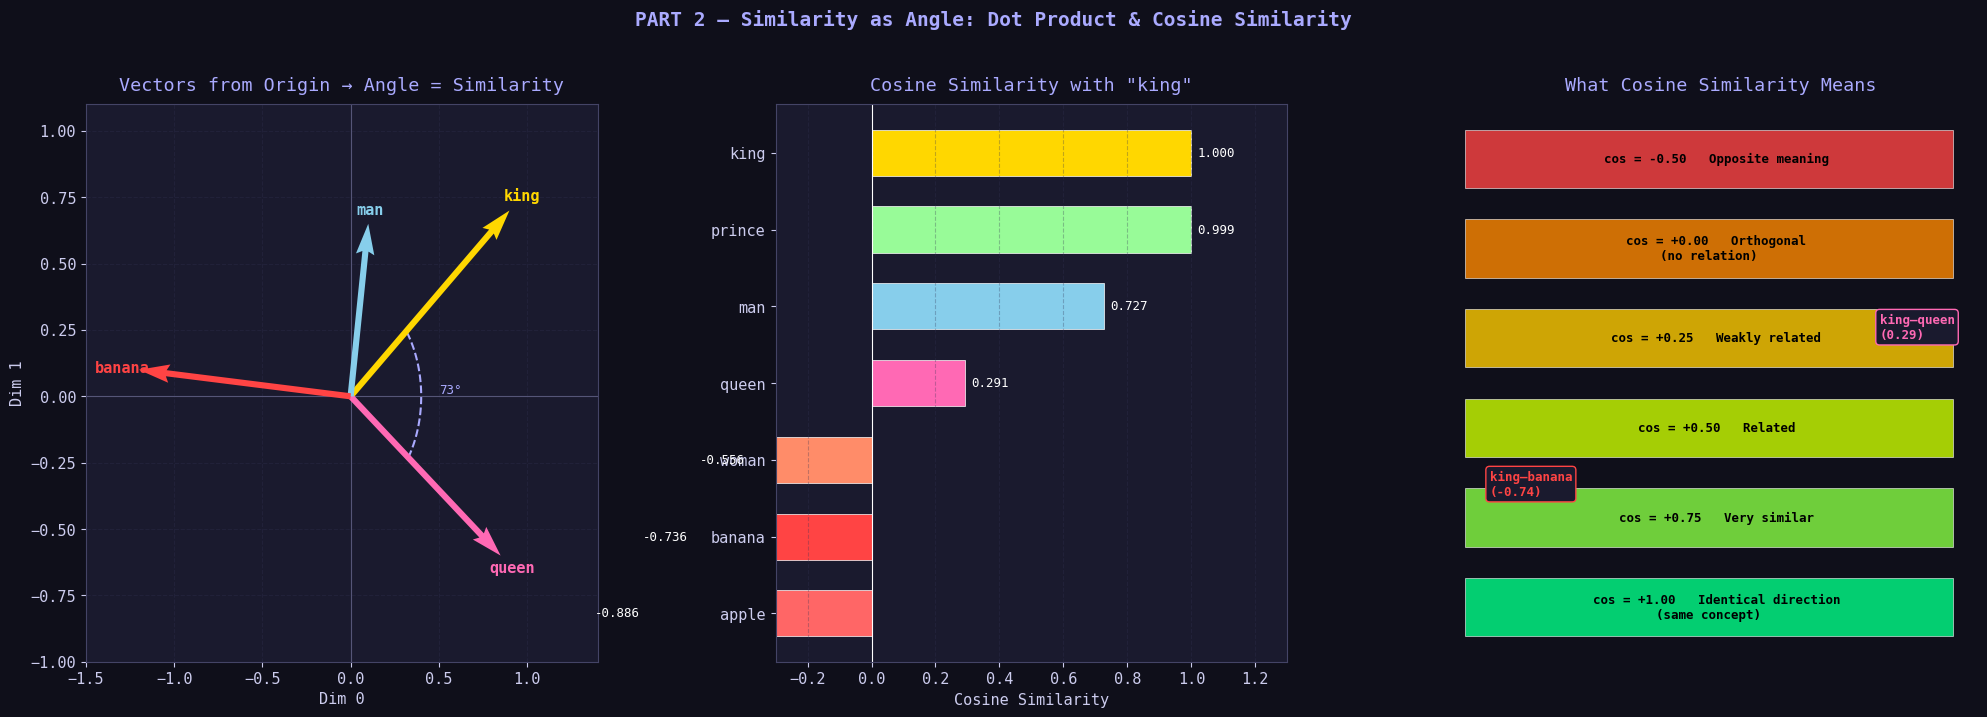

💡 Key insight: Cosine similarity ignores magnitude — pure direction.
   This is why search engines, recommendation systems, and LLMs use it.


In [34]:



# ── Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('PART 2 — Similarity as Angle: Dot Product & Cosine Similarity',
             fontsize=14, fontweight='bold', color='#aaaaff', y=1.02)

# ── LEFT: Vectors + angles ─────────────────────────────────────────────
ax = axes[0]
ax.set_title('Vectors from Origin → Angle = Similarity', color='#aaaaff', pad=10)

focus_words = ['king', 'queen', 'man', 'banana']
focus_colors = {'king': '#FFD700', 'queen': '#FF69B4', 'man': '#87CEEB', 'banana': '#FF4444'}

for word in focus_words:
    vec = words[word]
    c = focus_colors[word]
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1,
              color=c, width=0.012, zorder=5)
    ax.annotate(word, vec * 1.08, color=c, fontsize=11, fontweight='bold',
                ha='center', va='center')

# Draw arc for king-queen angle
theta_k = np.degrees(np.arctan2(words['king'][1], words['king'][0]))
theta_q = np.degrees(np.arctan2(words['queen'][1], words['queen'][0]))
theta_arr = np.linspace(np.radians(min(theta_k,theta_q)),
                         np.radians(max(theta_k,theta_q)), 50)
r_arc = 0.4
ax.plot(r_arc*np.cos(theta_arr), r_arc*np.sin(theta_arr),
        color='#aaaaff', lw=1.5, linestyle='--')
mid_angle = (np.radians(theta_k) + np.radians(theta_q)) / 2
ax.text(0.5*np.cos(mid_angle), 0.5*np.sin(mid_angle),
        f'{angle_degrees(words["king"], words["queen"]):.0f}°',
        color='#aaaaff', fontsize=9)

ax.axhline(0, color='#555577', lw=0.8)
ax.axvline(0, color='#555577', lw=0.8)
ax.set_xlim(-1.5, 1.4)
ax.set_ylim(-1.0, 1.1)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Dim 0')
ax.set_ylabel('Dim 1')

# ── CENTER: Cosine similarity bar chart ──────────────────────────────
ax2 = axes[1]
ax2.set_title('Cosine Similarity with "king"', color='#aaaaff', pad=10)

sorted_results = sorted(results, key=lambda x: -x[2])
word_labels = [r[0] for r in sorted_results]
cos_vals    = [r[2] for r in sorted_results]
bar_colors  = [colors.get(w, '#888888') for w in word_labels]

bars = ax2.barh(word_labels, cos_vals, color=bar_colors, edgecolor='white',
                linewidth=0.5, height=0.6)
for bar, val in zip(bars, cos_vals):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', color='white', fontsize=9)

ax2.axvline(0, color='white', lw=0.8)
ax2.set_xlim(-0.3, 1.3)
ax2.set_xlabel('Cosine Similarity')
ax2.grid(True, axis='x', alpha=0.3)
ax2.invert_yaxis()

# ── RIGHT: Angle heatmap interpretation ──────────────────────────────
ax3 = axes[2]
ax3.set_title('What Cosine Similarity Means', color='#aaaaff', pad=10)

# Reference guide
guide = [
    (1.00, '#00FF88', 'Identical direction\n(same concept)'),
    (0.75, '#88FF44', 'Very similar'),
    (0.50, '#CCFF00', 'Related'),
    (0.25, '#FFCC00', 'Weakly related'),
    (0.00, '#FF8800', 'Orthogonal\n(no relation)'),
    (-0.5, '#FF4444', 'Opposite meaning'),
]

ys = np.linspace(0, 1, len(guide))
for (val, col, label), y in zip(guide, ys):
    ax3.barh(y, 1.0, color=col, alpha=0.8, height=0.13,
             edgecolor='white', linewidth=0.5)
    ax3.text(0.5, y, f'  cos = {val:+.2f}   {label}',
             va='center', ha='center', color='black', fontsize=9,
             fontweight='bold')

# Plot actual king-queen and king-banana dots
cs_kq = cosine_similarity(words['king'], words['queen'])
cs_kb = cosine_similarity(words['king'], words['banana'])
ax3.annotate(f'king–queen\n({cs_kq:.2f})', xy=(0.85, 0.6), fontsize=9,
             color='#FF69B4', fontweight='bold',
             bbox=dict(boxstyle='round', fc='#1a1a2e', ec='#FF69B4'))
ax3.annotate(f'king–banana\n({cs_kb:.2f})', xy=(0.05, 0.25), fontsize=9,
             color='#FF4444', fontweight='bold',
             bbox=dict(boxstyle='round', fc='#1a1a2e', ec='#FF4444'))

ax3.axis('off')

plt.tight_layout()
plt.savefig('part2_similarity_as_angle.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('💡 Key insight: Cosine similarity ignores magnitude — pure direction.')
print('   This is why search engines, recommendation systems, and LLMs use it.')

---

##  PART 3 — Meaning as Direction
### *The most famous equation in NLP: king − man + woman = queen*

---

Here's where it gets philosophical.

If words are vectors, then **relationships between words are also vectors** — they're just directions in the embedding space.

The "royalty direction" isn't named anywhere. But it exists:

$$\text{royalty\_direction} = \text{king} - \text{man}$$

This direction represents: *"what makes a king different from an ordinary man."*

Now, if I take **woman** and add this direction... I should land near **queen**.

$$\text{woman} + (\text{king} - \text{man}) \approx \text{queen}$$

This is **not a trick**. It's geometry. The structure of language is encoded in the vector space.

---

###  Concept: Projection

**Projection** answers: *how much of vector **b** lies in the direction of **a**?*

$$\text{proj}_{\mathbf{a}}(\mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|^2} \mathbf{a}$$

The scalar part $\frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|}$ tells you the **score** — how much of concept **a** is present in word **b**.

Example: *How "royal" is the word "prince"?* → Project **prince** onto the royalty direction.

In [35]:
def projection_score(direction, word_vec):
    """Scalar projection: how much of 'word_vec' lies in 'direction'"""
    direction = np.array(direction)
    word_vec  = np.array(word_vec)
    return np.dot(word_vec, direction) / np.linalg.norm(direction)

def projection_vector(direction, word_vec):
    """Vector projection: the component of word_vec in direction"""
    d = np.array(direction)
    v = np.array(word_vec)
    return (np.dot(v, d) / np.dot(d, d)) * d

In [36]:
royalty_dir = words['king']  - words['man']    # royalty direction
gender_dir  = words['woman'] - words['man']    # gender direction

print('=== SEMANTIC DIRECTIONS ===')
print(f'  royalty_direction = king  − man   = {royalty_dir}')
print(f'  gender_direction  = woman − man   = {gender_dir}')

# ── Semantic arithmetic ───────────────────────────────────────────────
print()
print('=== SEMANTIC ARITHMETIC: king − man + woman = ?')
result = words['king'] - words['man'] + words['woman']
print(f'  Result vector: {result}')
print()
scores = {}
print('  Cosine similarity of result to each word:')
for word, vec in words.items():
    cs = cosine_similarity(result, vec)
    bar = '█' * int(cs * 20) if cs > 0 else ''
    print(f'    {word:<8} {cs:+.4f}  {bar}')


=== SEMANTIC DIRECTIONS ===
  royalty_direction = king  − man   = [0.8  0.05]
  gender_direction  = woman − man   = [-0.05 -1.35]

=== SEMANTIC ARITHMETIC: king − man + woman = ?
  Result vector: [ 0.85 -0.65]

  Cosine similarity of result to each word:
    king     +0.2541  █████
    queen    +0.9993  ███████████████████
    man      -0.4796  
    woman    +0.6625  █████████████
    prince   +0.2933  █████
    banana   -0.8421  
    apple    -0.6729  


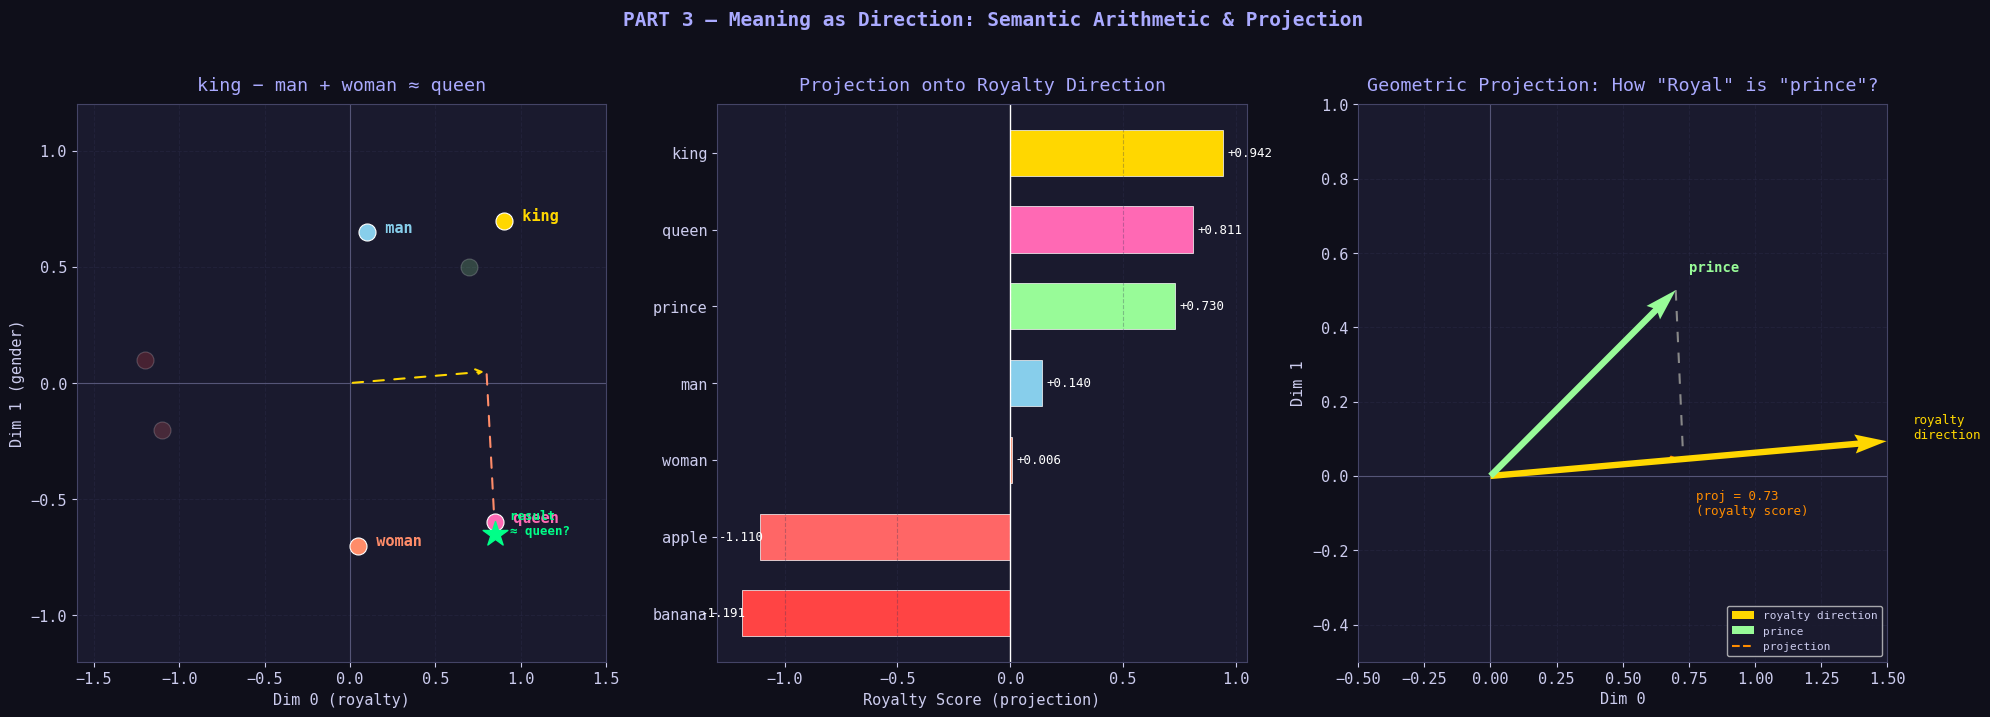

💡 Key insight: Relationships between words = vectors in space.
   Projection = semantic scoring. Linear algebra is semantic reasoning.


In [53]:
# ── Visualization ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('PART 3 — Meaning as Direction: Semantic Arithmetic & Projection',
             fontsize=14, fontweight='bold', color='#aaaaff', y=1.02)

# ── LEFT: Semantic arithmetic visualization ────────────────────────
ax = axes[0]
ax.set_title('king − man + woman ≈ queen', color='#aaaaff', pad=10)

k, m, w, q = words['king'], words['man'], words['woman'], words['queen']

# Draw all word vectors
for word, vec in words.items():
    c = colors[word]
    alpha = 1.0 if word in ['king','man','woman','queen'] else 0.2
    ax.scatter(*vec, s=150, color=c, zorder=5, alpha=alpha,
               edgecolors='white', linewidths=0.8)
    if word in ['king','man','woman','queen']:
        ax.annotate(f'  {word}', vec, color=c, fontsize=11, fontweight='bold')

# Draw the arithmetic path: king → (king - man) → (king - man + woman)
# Step 1: king - man (royalty direction)
ax.annotate('', xy=k - m, xytext=np.array([0,0]),
             arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1.5, linestyle=(0, (5, 5))))
# Step 2: add woman
ax.annotate('', xy=result, xytext=k - m,
             arrowprops=dict(arrowstyle='->', color='#FF8C69', lw=1.5, linestyle=(0, (5, 5))))
# Mark result
ax.scatter(*result, s=350, color='#00FF88', zorder=8, marker='*')
ax.annotate(f'  result\n  ≈ queen?', result, color='#00FF88', fontsize=9, fontweight='bold')

ax.axhline(0, color='#555577', lw=0.8)
ax.axvline(0, color='#555577', lw=0.8)
ax.set_xlim(-1.6, 1.5)
ax.set_ylim(-1.2, 1.2)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Dim 0 (royalty)')
ax.set_ylabel('Dim 1 (gender)')

# ── CENTER: Royalty projection scores ─────────────────────────────
ax2 = axes[1]
ax2.set_title('Projection onto Royalty Direction', color='#aaaaff', pad=10)

sorted_scores = sorted(scores.items(), key=lambda x: -x[1])
ws = [s[0] for s in sorted_scores]
vs = [s[1] for s in sorted_scores]
cs_bar = [colors.get(w, '#888888') for w in ws]

bars = ax2.barh(ws, vs, color=cs_bar, edgecolor='white', linewidth=0.5, height=0.6)
for bar, val in zip(bars, vs):
    x_pos = val + 0.02 if val >= 0 else val - 0.18
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:+.3f}', va='center', color='white', fontsize=9)

ax2.axvline(0, color='white', lw=1)
ax2.set_xlabel('Royalty Score (projection)')
ax2.grid(True, axis='x', alpha=0.3)
ax2.invert_yaxis()

# ── RIGHT: What projection looks like geometrically ───────────────────────
ax3 = axes[2]
ax3.set_title('Geometric Projection: How "Royal" is "prince"?', color='#aaaaff', pad=10)

# Show royalty direction and project prince onto it
r_dir_norm = royalty_dir / np.linalg.norm(royalty_dir)
prince_vec  = words['prince']
proj_vec    = projection_vector(royalty_dir, prince_vec)

# Royalty direction arrow
ax3.quiver(0, 0, r_dir_norm[0]*1.5, r_dir_norm[1]*1.5,
           angles='xy', scale_units='xy', scale=1,
           color='#FFD700', width=0.012, zorder=5,
           label='royalty direction')
ax3.text(r_dir_norm[0]*1.6, r_dir_norm[1]*1.6, 'royalty\ndirection',
         color='#FFD700', fontsize=9)

# Prince vector
ax3.quiver(0, 0, prince_vec[0], prince_vec[1],
           angles='xy', scale_units='xy', scale=1,
           color='#98FB98', width=0.012, zorder=5,
           label='prince')
ax3.text(prince_vec[0]+0.05, prince_vec[1]+0.05, 'prince',
         color='#98FB98', fontsize=10, fontweight='bold')

# Projection vector
# Projection vector (dashed arrow) — quiver linestyle problemi var, ona görə annotate istifadə edirik
ax3.annotate(
    '', xy=proj_vec, xytext=(0, 0),
    arrowprops=dict(arrowstyle='->', color='#FF8C00', lw=2, linestyle='--')
)
# İstəsən label üçün “dummy” xətt:
ax3.plot([], [], '--', color='#FF8C00', label='projection')

# Perpendicular line (residual)
ax3.plot([prince_vec[0], proj_vec[0]], [prince_vec[1], proj_vec[1]],
         linestyle=(0, (5, 5)), color='#888888', lw=1.5)
ax3.text(proj_vec[0]+0.05, proj_vec[1]-0.15,
         f'proj = {np.linalg.norm(proj_vec):.2f}\n(royalty score)',
         color='#FF8C00', fontsize=9)

ax3.axhline(0, color='#555577', lw=0.8)
ax3.axvline(0, color='#555577', lw=0.8)
ax3.set_xlim(-0.5, 1.5)
ax3.set_ylim(-0.5, 1.0)
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('Dim 0')
ax3.set_ylabel('Dim 1')
ax3.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('part3_meaning_as_direction.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('💡 Key insight: Relationships between words = vectors in space.')
print('   Projection = semantic scoring. Linear algebra is semantic reasoning.')


---

##  PART 4 — How Embeddings Are Created
### *Matrix multiplication is just efficient lookup — until it isn't*

---

We've been using embeddings like they just *exist*. But where do they come from?

**Step 1:** Every word starts as a **one-hot vector** — a vector of all zeros with a single 1.

```
Vocabulary: [king, queen, man, woman, banana]
king  → [1, 0, 0, 0, 0]
queen → [0, 1, 0, 0, 0]
man   → [0, 0, 1, 0, 0]
```

This is useless for similarity — but it gives us a starting point.

**Step 2:** Multiply by a learned **embedding matrix** W:

$$\text{embedding} = W \cdot \mathbf{x}_{\text{one-hot}}$$

- W is shape **(embedding_dim × vocab_size)**  
- Multiplying W by a one-hot vector **selects one column** from W
- Each column = the embedding for one word

**This is the core insight:** matrix multiplication isn't about arithmetic — it's a **routing operation**. One-hot input routes to the correct embedding row.

And W is learned during training — gradient descent adjusts it so similar words end up with similar vectors.

---

###  Concept: Matrix Multiplication

$$C = AB \quad \Rightarrow \quad C_{ij} = \sum_k A_{ik} B_{kj}$$

Each output is a **dot product** of a row of A with a column of B.

Intuition: A transforms the space. B provides the input. C is the result.

In [40]:
vocab = ['king', 'queen', 'man', 'woman', 'prince', 'banana', 'apple']
vocab_size = len(vocab)
embedding_dim = 2  # Using 2D for visualization

In [41]:
W = np.column_stack([words[w] for w in vocab])  # shape: (2, 7)

print(f'Embedding matrix W — shape: {W.shape}  (embedding_dim × vocab_size)')
print(f'  Rows = {embedding_dim} embedding dimensions')
print(f'  Cols = {vocab_size} words in vocabulary')
print()

print('W matrix:')
for i, row in enumerate(W):
    print(f'  Dim {i}: [{"  ".join(f"{v:+.2f}" for v in row)}]')

Embedding matrix W — shape: (2, 7)  (embedding_dim × vocab_size)
  Rows = 2 embedding dimensions
  Cols = 7 words in vocabulary

W matrix:
  Dim 0: [+0.90  +0.85  +0.10  +0.05  +0.70  -1.20  -1.10]
  Dim 1: [+0.70  -0.60  +0.65  -0.70  +0.50  +0.10  -0.20]


In [42]:
def one_hot(word_idx, size):
    v = np.zeros(size)
    v[word_idx] = 1.0
    return v

print()
print('=== ONE-HOT VECTORS ===')
for i, word in enumerate(vocab):
    oh = one_hot(i, vocab_size)
    print(f'  {word:<8} → {oh.astype(int)}')


=== ONE-HOT VECTORS ===
  king     → [1 0 0 0 0 0 0]
  queen    → [0 1 0 0 0 0 0]
  man      → [0 0 1 0 0 0 0]
  woman    → [0 0 0 1 0 0 0]
  prince   → [0 0 0 0 1 0 0]
  banana   → [0 0 0 0 0 1 0]
  apple    → [0 0 0 0 0 0 1]


In [43]:
print()
print('=== MATRIX MULTIPLICATION: W × one_hot = embedding ===')
for i, word in enumerate(vocab):
    oh = one_hot(i, vocab_size)
    embedding = W @ oh  # Matrix multiply
    direct    = words[word]  # Direct lookup
    match = '✅' if np.allclose(embedding, direct) else '❌'
    print(f'  W × one_hot("{word}") = {embedding}  {match} matches direct lookup')


=== MATRIX MULTIPLICATION: W × one_hot = embedding ===
  W × one_hot("king") = [0.9 0.7]  ✅ matches direct lookup
  W × one_hot("queen") = [ 0.85 -0.6 ]  ✅ matches direct lookup
  W × one_hot("man") = [0.1  0.65]  ✅ matches direct lookup
  W × one_hot("woman") = [ 0.05 -0.7 ]  ✅ matches direct lookup
  W × one_hot("prince") = [0.7 0.5]  ✅ matches direct lookup
  W × one_hot("banana") = [-1.2  0.1]  ✅ matches direct lookup
  W × one_hot("apple") = [-1.1 -0.2]  ✅ matches direct lookup


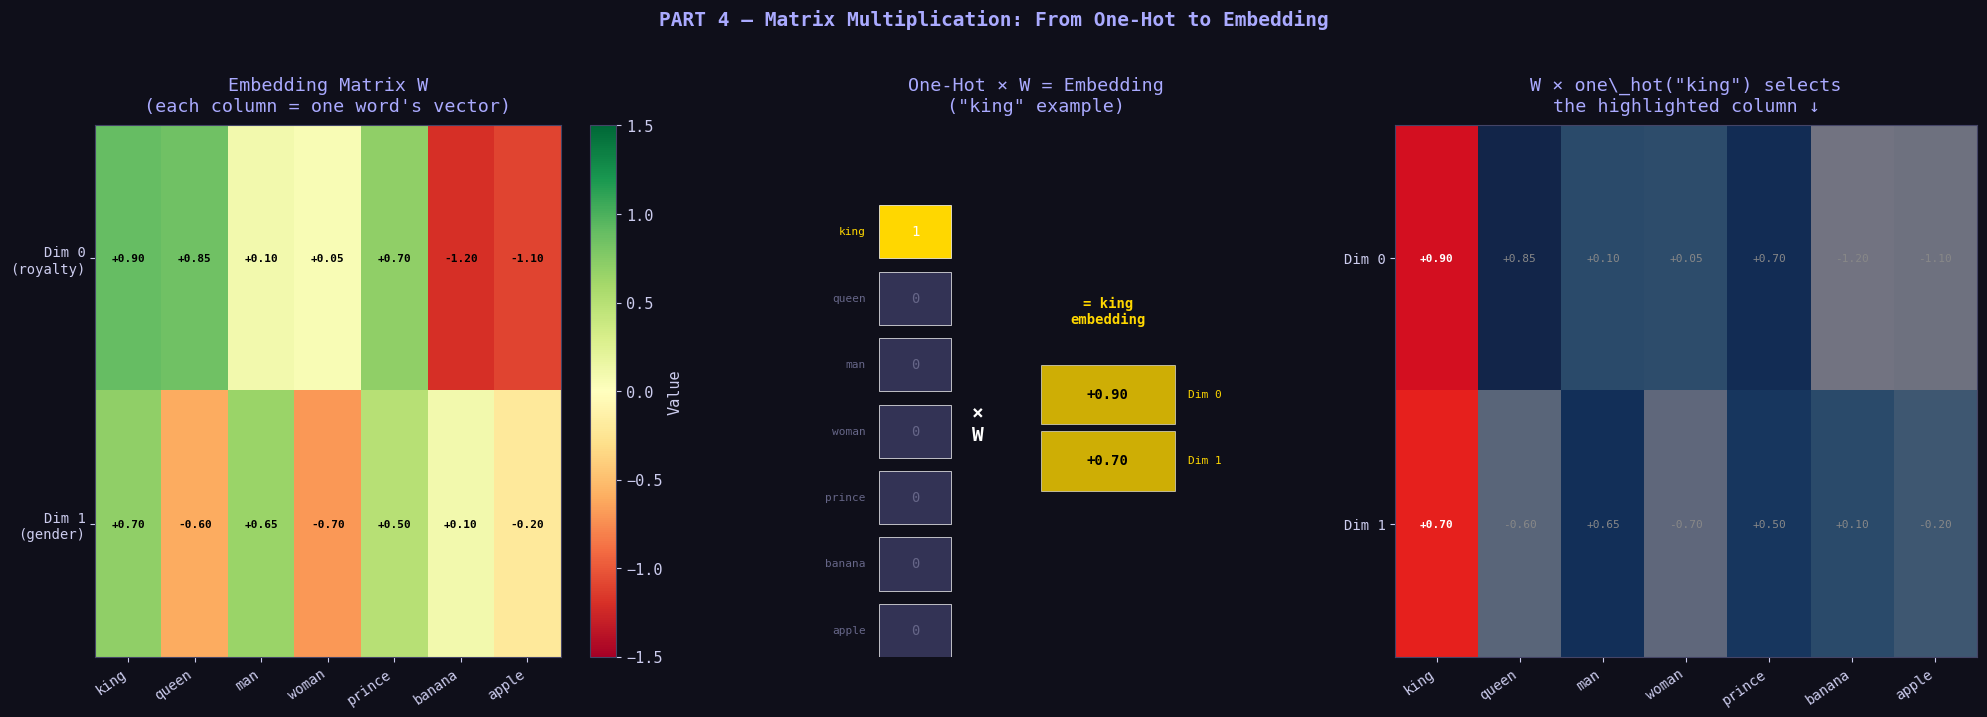

💡 Key insight: Matrix multiplication = routing information through space.
   W × one_hot = "select the embedding" — but W is LEARNED by the model.


In [44]:



# ── Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('PART 4 — Matrix Multiplication: From One-Hot to Embedding',
             fontsize=14, fontweight='bold', color='#aaaaff', y=1.02)

# ── LEFT: The embedding matrix as a heatmap ───────────────────────────
ax = axes[0]
ax.set_title('Embedding Matrix W\n(each column = one word\'s vector)',
             color='#aaaaff', pad=10)

im = ax.imshow(W, cmap='RdYlGn', aspect='auto', vmin=-1.5, vmax=1.5)
plt.colorbar(im, ax=ax, label='Value')
ax.set_xticks(range(vocab_size))
ax.set_xticklabels(vocab, rotation=35, ha='right', fontsize=10)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Dim 0\n(royalty)', 'Dim 1\n(gender)'], fontsize=10)

for i in range(2):
    for j in range(vocab_size):
        ax.text(j, i, f'{W[i,j]:+.2f}', ha='center', va='center',
                color='black', fontsize=8, fontweight='bold')

# ── CENTER: One-hot × matrix = embedding (diagram) ────────────────────
ax2 = axes[1]
ax2.set_title('One-Hot × W = Embedding\n("king" example)', color='#aaaaff', pad=10)

# Visual equation
n = vocab_size
king_idx = vocab.index('king')
oh = one_hot(king_idx, n)

# Draw one-hot vector
for i, v in enumerate(oh):
    color = '#FFD700' if i == king_idx else '#333355'
    rect = plt.Rectangle((0, n - i - 1), 0.8, 0.8, color=color,
                          ec='white', lw=0.5)
    ax2.add_patch(rect)
    ax2.text(0.4, n - i - 0.6, str(int(v)), ha='center', va='center',
             color='white' if i == king_idx else '#666688', fontsize=10)
    ax2.text(-0.15, n - i - 0.6, vocab[i], ha='right', va='center',
             color='#FFD700' if i == king_idx else '#666688', fontsize=8)

ax2.text(1.1, n/2, '×\nW', ha='center', va='center', color='white',
         fontsize=14, fontweight='bold')

# Draw result embedding
result_emb = W @ oh
for i, v in enumerate(result_emb):
    col = '#FFD700'
    rect = plt.Rectangle((1.8, len(result_emb) - i + 1.5), 1.5, 0.9,
                          color=col, alpha=0.8, ec='white', lw=0.5)
    ax2.add_patch(rect)
    ax2.text(2.55, len(result_emb) - i + 1.95, f'{v:+.2f}',
             ha='center', va='center', color='black', fontsize=10, fontweight='bold')
    ax2.text(3.45, len(result_emb) - i + 1.95,
             f'Dim {i}', ha='left', va='center', color='#FFD700', fontsize=8)

ax2.text(2.55, 5.2, '= king\nembedding', ha='center', va='center',
         color='#FFD700', fontsize=10, fontweight='bold')

ax2.set_xlim(-1.5, 5.0)
ax2.set_ylim(0, 8)
ax2.axis('off')

# ── RIGHT: Matrix multiply step-by-step heatmap ───────────────────────
ax3 = axes[2]
ax3.set_title('Embedding Lookup = Column Selection', color='#aaaaff', pad=10)

im2 = ax3.imshow(W, cmap='Blues', aspect='auto', alpha=0.4)
# Highlight the king column
highlight_col = np.zeros_like(W)
highlight_col[:, king_idx] = W[:, king_idx]
im3 = ax3.imshow(np.ma.masked_where(highlight_col == 0, highlight_col),
                 cmap='YlOrRd', aspect='auto', vmin=-1.5, vmax=1.5)

ax3.set_xticks(range(vocab_size))
ax3.set_xticklabels(vocab, rotation=35, ha='right', fontsize=10)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Dim 0', 'Dim 1'], fontsize=10)

for i in range(2):
    for j in range(vocab_size):
        fc = 'white' if j == king_idx else '#888888'
        fw = 'bold' if j == king_idx else 'normal'
        ax3.text(j, i, f'{W[i,j]:+.2f}', ha='center', va='center',
                 color=fc, fontsize=8, fontweight=fw)

ax3.set_title('W × one\_hot("king") selects\nthe highlighted column ↓',
              color='#aaaaff', pad=10)

plt.tight_layout()
plt.savefig('part4_matrix_multiplication.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('💡 Key insight: Matrix multiplication = routing information through space.')
print('   W × one_hot = "select the embedding" — but W is LEARNED by the model.')

---

##  PART 5 — Neural Networks as Space Transformers
### *Every layer reshapes geometry*

---

When a word embedding passes through a neural network layer:

$$\mathbf{z} = W\mathbf{x}$$

This is a **linear transformation**. The matrix W doesn't just compute numbers — it **reshapes space**.

What can a linear transformation do?

- **Rotate** — change the orientation of the space  
- **Scale** — stretch or compress certain directions  
- **Reflect** — flip across an axis  
- **Project** — collapse from higher to lower dimensions  

What can't it do? **Curve** things. Linear transformations always keep lines straight.
(That's why we add non-linearities like ReLU — to introduce curves.)

The network is essentially asking: *"What transformation of semantic space makes it easier to predict the next word / classify sentiment / translate text?"*

---

###  Concept: Linear Transformation

A matrix W defines a function $T(\mathbf{x}) = W\mathbf{x}$ that maps every point in one space to a point in another.

Properties guaranteed: straight lines stay straight, origin stays fixed, parallel lines stay parallel.

In [45]:
def apply_transform(W, points):
    """Apply matrix transformation to a set of 2D points"""
    return (W @ points.T).T

# Create a grid of points to visualize the transformation
x_range = np.linspace(-1.5, 1.5, 15)
y_range = np.linspace(-1.5, 1.5, 15)
xx, yy = np.meshgrid(x_range, y_range)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

In [46]:
transforms = {
    'Rotation\n(30°)': np.array([
        [np.cos(np.pi/6), -np.sin(np.pi/6)],
        [np.sin(np.pi/6),  np.cos(np.pi/6)]
    ]),
    'Shear\n(stretch royalty)': np.array([
        [1.8, 0.3],
        [0.1, 0.7]
    ]),
    'Reflection\n(flip gender axis)': np.array([
        [1.0,  0.0],
        [0.0, -1.0]
    ]),
    'Compression\n(to 1D subspace)': np.array([
        [0.9, 0.2],
        [0.2, 0.05]
    ]),
}

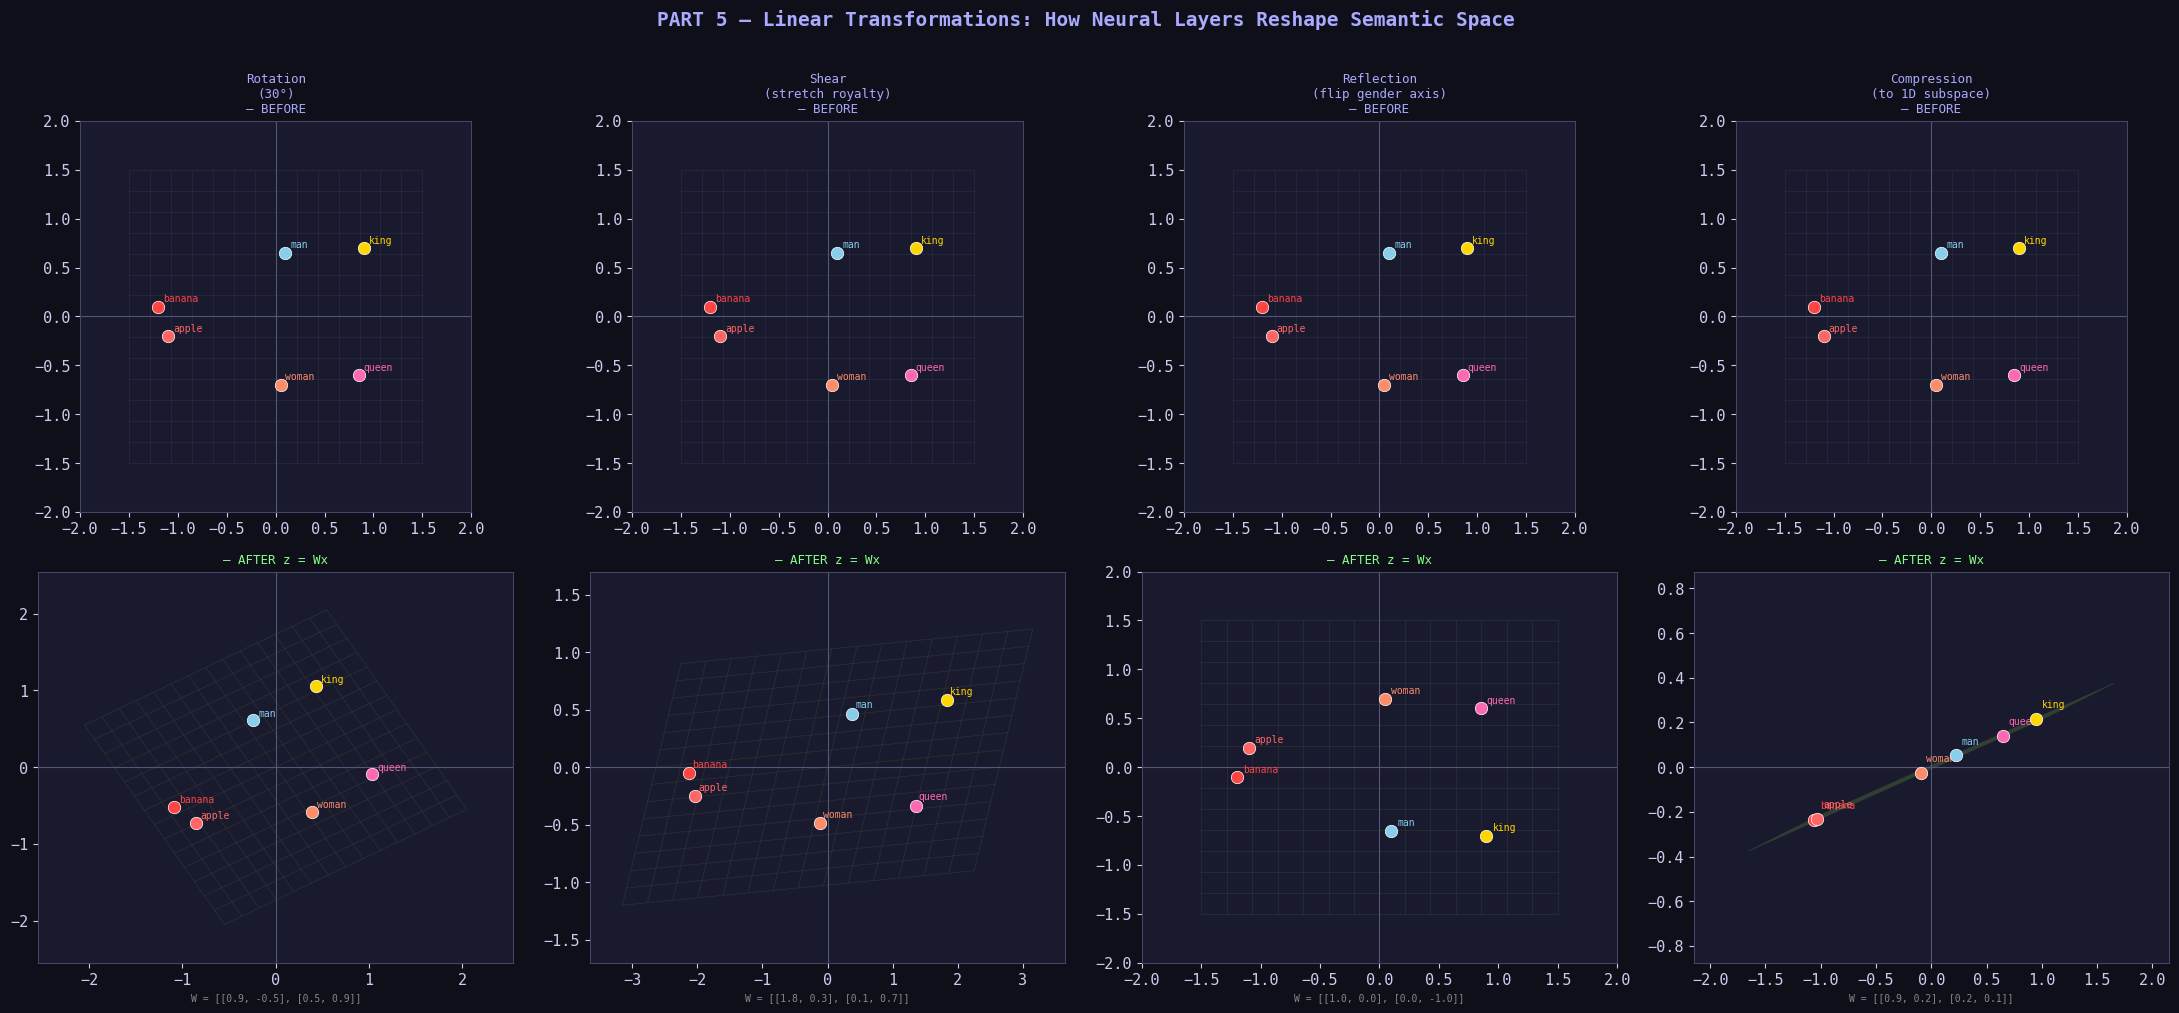

💡 Key insight: Each neural layer = one linear transformation.
   The network learns W values that make semantic space more useful.
   Notice: lines stay straight. To bend space, we need non-linearities (ReLU, GELU...).


In [47]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('PART 5 — Linear Transformations: How Neural Layers Reshape Semantic Space',
             fontsize=14, fontweight='bold', color='#aaaaff', y=1.01)

word_pts = np.array([words[w] for w in ['king','queen','man','woman','banana','apple']])
word_labels_short = ['king','queen','man','woman','banana','apple']
word_colors_list  = [colors[w] for w in word_labels_short]

for col_idx, (name, W_t) in enumerate(transforms.items()):
    # ── BEFORE ────────────────────────────────────────────────────────
    ax_before = axes[0][col_idx]
    ax_before.set_title(f'{name}\n— BEFORE', color='#aaaaff', fontsize=9, pad=6)

    # Grid lines
    for i in range(len(x_range)):
        col_pts = grid_points[i::len(x_range)]
        ax_before.plot(col_pts[:,0], col_pts[:,1], color='#333355', lw=0.5, alpha=0.6)
    for j in range(len(y_range)):
        row_pts = grid_points[j*len(x_range):(j+1)*len(x_range)]
        ax_before.plot(row_pts[:,0], row_pts[:,1], color='#333355', lw=0.5, alpha=0.6)

    # Word vectors
    for pt, label, c in zip(word_pts, word_labels_short, word_colors_list):
        ax_before.scatter(*pt, s=80, color=c, zorder=5, edgecolors='white', lw=0.5)
        ax_before.text(pt[0]+0.05, pt[1]+0.05, label, color=c, fontsize=7)

    ax_before.set_xlim(-2, 2)
    ax_before.set_ylim(-2, 2)
    ax_before.axhline(0, color='#555577', lw=0.8)
    ax_before.axvline(0, color='#555577', lw=0.8)
    ax_before.set_aspect('equal')
    ax_before.grid(False)

    # ── AFTER ─────────────────────────────────────────────────────────
    ax_after = axes[1][col_idx]
    ax_after.set_title(f'— AFTER z = Wx', color='#88ff88', fontsize=9, pad=6)

    transformed_grid = apply_transform(W_t, grid_points)
    transformed_words = apply_transform(W_t, word_pts)

    # Transformed grid lines
    for i in range(len(x_range)):
        col_pts = transformed_grid[i::len(x_range)]
        ax_after.plot(col_pts[:,0], col_pts[:,1], color='#334433', lw=0.5, alpha=0.6)
    for j in range(len(y_range)):
        row_pts = transformed_grid[j*len(x_range):(j+1)*len(x_range)]
        ax_after.plot(row_pts[:,0], row_pts[:,1], color='#334433', lw=0.5, alpha=0.6)

    # Transformed word vectors
    for pt, label, c in zip(transformed_words, word_labels_short, word_colors_list):
        ax_after.scatter(*pt, s=80, color=c, zorder=5, edgecolors='white', lw=0.5)
        ax_after.text(pt[0]+0.05, pt[1]+0.05, label, color=c, fontsize=7)

    # Dynamic axis limits
    pad = 0.5
    x_min = transformed_grid[:,0].min() - pad
    x_max = transformed_grid[:,0].max() + pad
    y_min = transformed_grid[:,1].min() - pad
    y_max = transformed_grid[:,1].max() + pad
    ax_after.set_xlim(x_min, x_max)
    ax_after.set_ylim(y_min, y_max)
    ax_after.axhline(0, color='#555577', lw=0.8)
    ax_after.axvline(0, color='#555577', lw=0.8)
    ax_after.grid(False)

    # Print matrix
    mat_str = f'W = [[{W_t[0,0]:.1f}, {W_t[0,1]:.1f}], [{W_t[1,0]:.1f}, {W_t[1,1]:.1f}]]'
    ax_after.set_xlabel(mat_str, fontsize=7, color='#888888')

plt.tight_layout()
plt.savefig('part5_linear_transformations.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()
print('💡 Key insight: Each neural layer = one linear transformation.')
print('   The network learns W values that make semantic space more useful.')
print('   Notice: lines stay straight. To bend space, we need non-linearities (ReLU, GELU...).')

---

##  PART 6 — The Richness of Representation
### *Rank: how much information can a matrix hold?*

---

Here's a critical question: **can the embedding matrix W represent everything we need?**

The answer depends on its **rank** — the number of truly independent directions in the matrix.

Think of it this way:
- A rank-1 matrix = all rows are multiples of one row = everything collapses to a line
- A rank-2 matrix = information lives in a 2D plane  
- A full-rank matrix = rich, expressive, many independent directions

**Why does this matter for AI?**

- **Low rank** → the model can only represent simple patterns → underfitting
- **High rank** → the model can represent complex relationships → expressive
- **Forced low rank** → compression! (Used in LoRA, distillation, efficient transformers)

LoRA (Low-Rank Adaptation) — one of the most important fine-tuning techniques today — works by constraining weight matrices to be low-rank:
$$W \approx AB \quad \text{where } A \in \mathbb{R}^{m \times r}, B \in \mathbb{R}^{r \times n}, r \ll \min(m,n)$$

---

###  Concept: Rank of a Matrix

The rank of matrix A = the number of linearly independent rows (or columns).

$$\text{rank}(A) = \dim(\text{column space of } A)$$

If rank = k, the transformation only uses k dimensions — everything else collapses.

=== MATRIX RANK ANALYSIS ===
  Full matrix W_full  : shape (50, 100),  rank = 50 (full rank = rich representation)
  Low-rank  W_rank5   : shape (50, 100),  rank = 5 (compressed to 5 dimensions)
  Rank-1    W_rank1   : shape (50, 100),  rank = 1 (everything on a line — useless)

=== SINGULAR VALUES (the "important dimensions") ===
  W_full: 50 non-zero singular values. Top 5: [17.17 15.84 15.76 14.73 14.62]
  W_rank5: 5 non-zero singular values. Top 5: [80.27 74.92 72.12 60.8  44.28]
  W_rank1: 1 non-zero singular values. Top 5: [84.27  0.    0.    0.    0.  ]


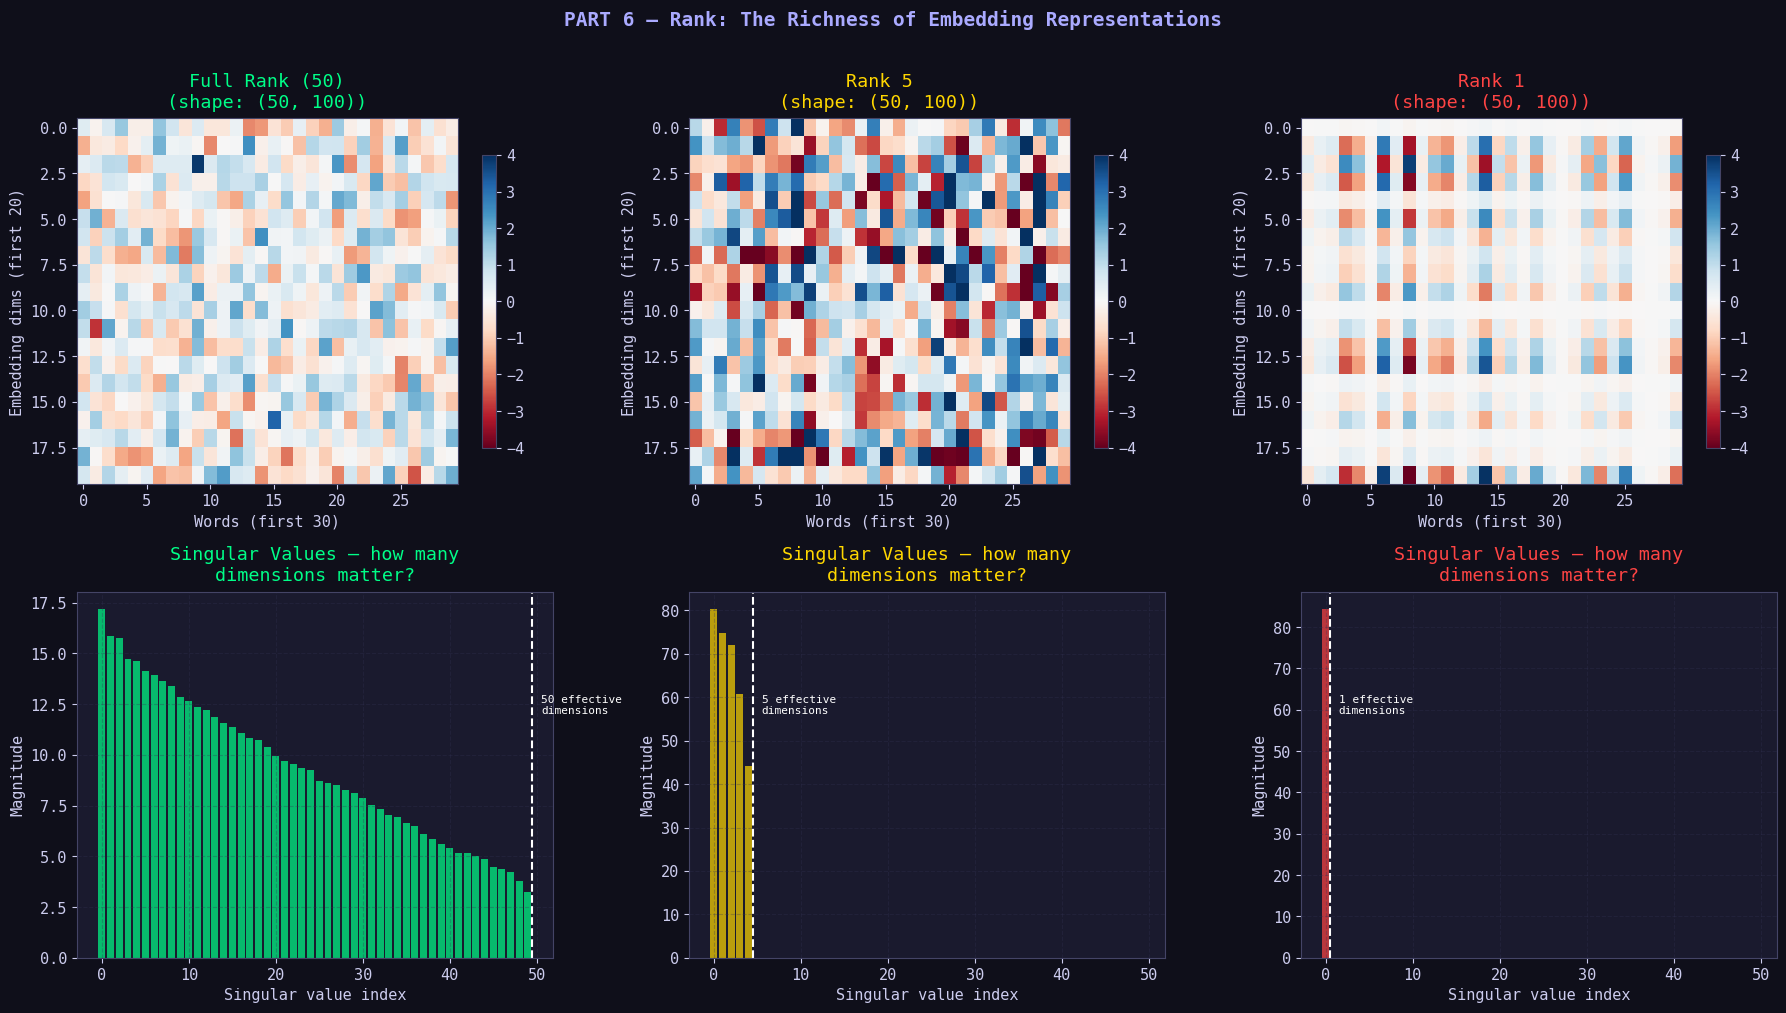

💡 Key insight: Rank = expressive capacity.
   LoRA, model compression, and efficient transformers all manipulate rank.
   More rank → richer representation, but also more parameters to learn.


In [48]:
np.random.seed(42)

# Create embedding matrices with different ranks
n = 100  # vocab size
d = 50   # embedding dimension

def make_rank_k_matrix(rows, cols, k):
    """Create a matrix with exactly rank k"""
    A = np.random.randn(rows, k)
    B = np.random.randn(k, cols)
    return A @ B  # rank = k (at most)

# Full-rank matrix (can represent many patterns)
W_full = np.random.randn(d, n)      # rank ≈ min(d,n) = 50
W_rank5  = make_rank_k_matrix(d, n, 5)   # rank = 5
W_rank1  = make_rank_k_matrix(d, n, 1)   # rank = 1

actual_ranks = [
    np.linalg.matrix_rank(W_full),
    np.linalg.matrix_rank(W_rank5),
    np.linalg.matrix_rank(W_rank1)
]

print('=== MATRIX RANK ANALYSIS ===')
print(f'  Full matrix W_full  : shape {W_full.shape},  rank = {actual_ranks[0]} (full rank = rich representation)')
print(f'  Low-rank  W_rank5   : shape {W_rank5.shape},  rank = {actual_ranks[1]} (compressed to 5 dimensions)')
print(f'  Rank-1    W_rank1   : shape {W_rank1.shape},  rank = {actual_ranks[2]} (everything on a line — useless)')

print()
print('=== SINGULAR VALUES (the "important dimensions") ===')
for name, W in [('W_full', W_full), ('W_rank5', W_rank5), ('W_rank1', W_rank1)]:
    sv = np.linalg.svd(W, compute_uv=False)
    nonzero = np.sum(sv > 0.01)
    print(f'  {name}: {nonzero} non-zero singular values. Top 5: {sv[:5].round(2)}')

# ── Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('PART 6 — Rank: The Richness of Embedding Representations',
             fontsize=14, fontweight='bold', color='#aaaaff', y=1.01)

matrices = [(W_full, f'Full Rank ({actual_ranks[0]})', '#00FF88'),
            (W_rank5, f'Rank 5', '#FFD700'),
            (W_rank1, f'Rank 1', '#FF4444')]

for col, (W, title, col_color) in enumerate(matrices):
    # ── Top row: matrix heatmap ────────────────────────────────────────
    ax = axes[0][col]
    ax.set_title(f'{title}\n(shape: {W.shape})', color=col_color, pad=8)

    im = ax.imshow(W[:20, :30], cmap='RdBu', aspect='auto', vmin=-4, vmax=4)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xlabel('Words (first 30)')
    ax.set_ylabel('Embedding dims (first 20)')

    # ── Bottom row: singular value spectrum ───────────────────────────
    ax2 = axes[1][col]
    ax2.set_title(f'Singular Values — how many\ndimensions matter?',
                  color=col_color, pad=8)

    sv = np.linalg.svd(W, compute_uv=False)
    ax2.bar(range(len(sv)), sv, color=col_color, alpha=0.7, width=0.8)
    ax2.set_xlabel('Singular value index')
    ax2.set_ylabel('Magnitude')
    ax2.grid(True, alpha=0.3)

    # Annotation
    effective = np.sum(sv > sv.max() * 0.01)
    ax2.axvline(effective - 0.5, color='white', lw=1.5, linestyle='--')
    ax2.text(effective + 0.5, sv.max() * 0.7,
             f'{effective} effective\ndimensions',
             color='white', fontsize=8)

plt.tight_layout()
plt.savefig('part6_rank.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💡 Key insight: Rank = expressive capacity.')
print('   LoRA, model compression, and efficient transformers all manipulate rank.')
print('   More rank → richer representation, but also more parameters to learn.')

---

##  PART 7 — Compressing Intelligence
### *Eigenvectors, SVD, and PCA: finding the skeleton of meaning*

---

We have 300-dimensional word vectors. But how much of that is truly *necessary*?

**PCA** (Principal Component Analysis) asks: *what are the main directions of variation in this dataset?*

Think of it as finding the "skeleton" of the data:
- The first principal component = the direction with the most spread
- The second = the next most important direction (perpendicular to the first)
- And so on...

These directions are **eigenvectors**. Their importances are **eigenvalues**.

---

###  Concept: Eigenvectors and Eigenvalues

For a matrix A, an eigenvector **v** satisfies:

$$A\mathbf{v} = \lambda\mathbf{v}$$

The transformation doesn't rotate this special vector — it only **scales** it by λ (the eigenvalue).

These are the "natural axes" of the transformation.

###  Concept: SVD (Singular Value Decomposition)

Any matrix W can be decomposed:

$$W = U \Sigma V^T$$

- U = left singular vectors (output space directions)
- Σ = singular values (importance of each direction)
- V = right singular vectors (input space directions)

Keep only the top-k singular values → best rank-k approximation of W. That's compression.

**This is exactly how image compression, LoRA, and PCA work.**

=== EIGENVECTORS DEMO ===
Matrix A = 
[[3. 1.]
 [1. 2.]]

  Eigenvector 1: v = [0.851 0.526],  λ = 3.618
  A×v = [3.078 1.902],   λ×v = [3.078 1.902]   ✅ Equal: True

  Eigenvector 2: v = [-0.526  0.851],  λ = 1.382
  A×v = [-0.727  1.176],   λ×v = [-0.727  1.176]   ✅ Equal: True

=== PCA ON 50D WORD EMBEDDINGS ===
  Input shape:  (31, 50)  (50 dimensional embeddings)
  After PCA:    (31, 10)  (reduced to 10 dimensions)

  Explained variance by component:
    PC 1: 0.368 (36.8% cumulative) █████████████████████████████████████████████████████████████████████████
    PC 2: 0.151 (51.9% cumulative) ██████████████████████████████
    PC 3: 0.055 (57.5% cumulative) ███████████
    PC 4: 0.046 (62.0% cumulative) █████████
    PC 5: 0.042 (66.2% cumulative) ████████
    PC 6: 0.039 (70.1% cumulative) ███████
    PC 7: 0.033 (73.5% cumulative) ██████
    PC 8: 0.032 (76.6% cumulative) ██████
    PC 9: 0.029 (79.6% cumulative) █████
    PC10: 0.027 (82.3% cumulative) █████


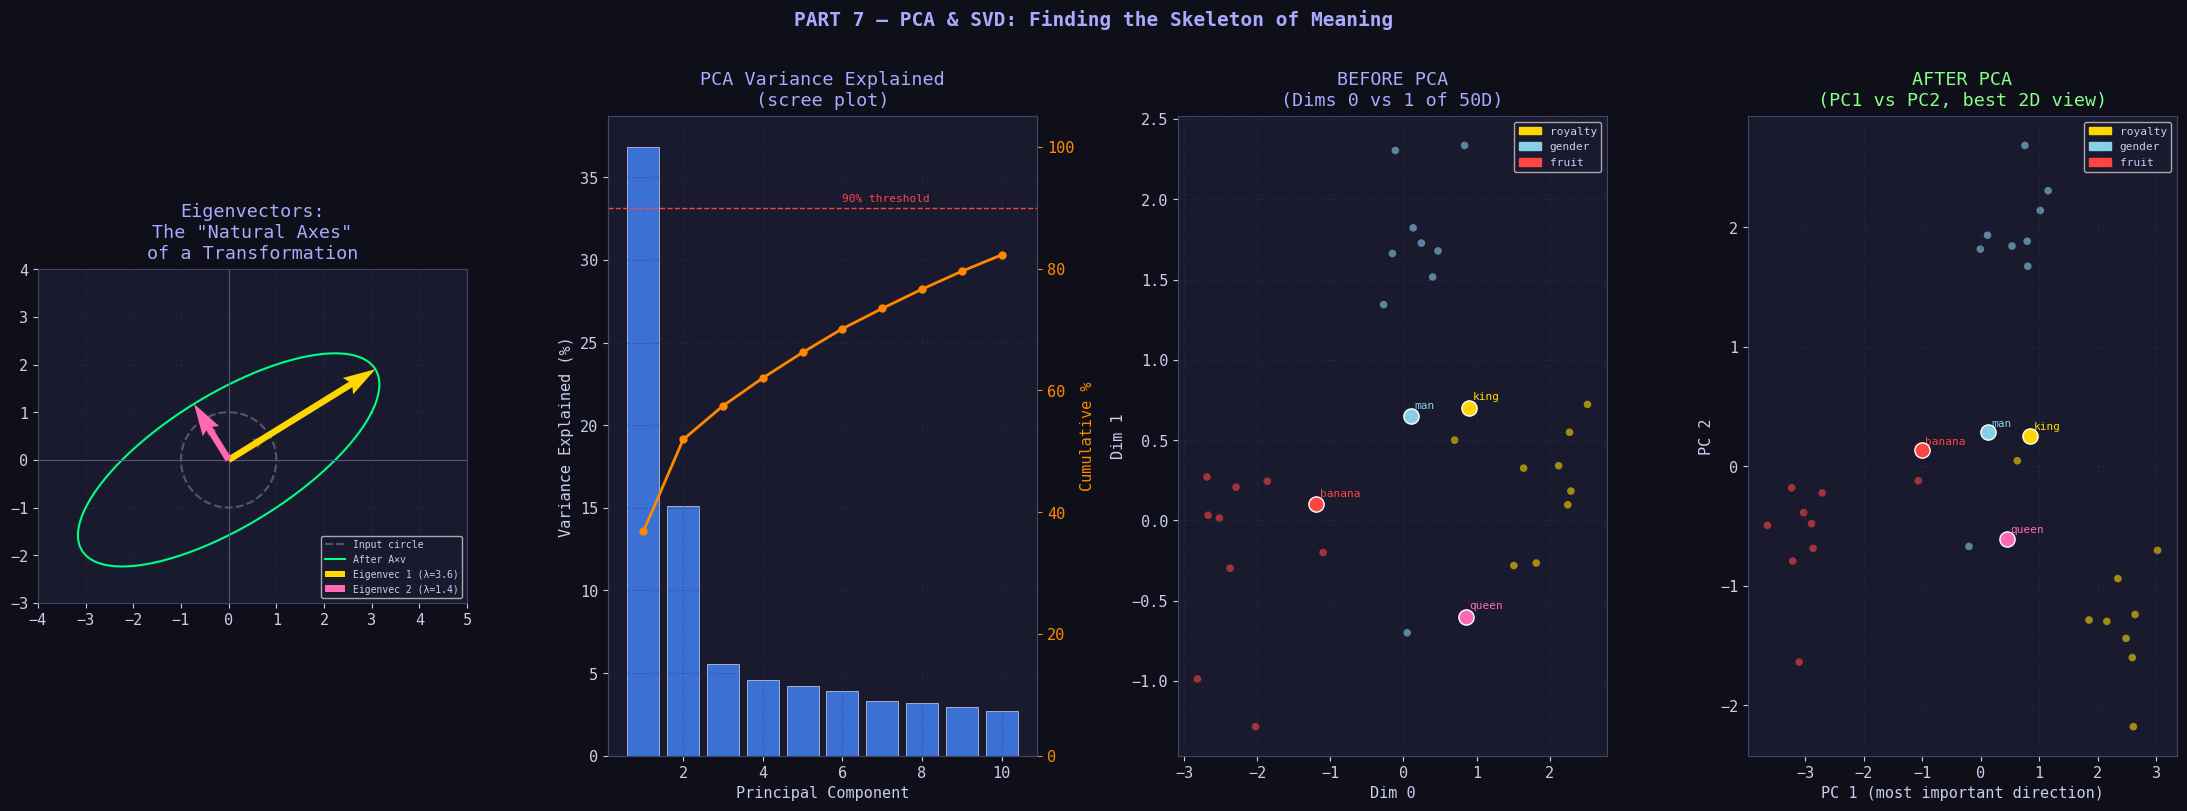

💡 Key insight: PCA finds the MOST IMPORTANT directions in embedding space.
   Clusters become visible. 50D collapses to 2D while preserving meaning.
   This is how GPT, BERT and others are compressed for deployment.


In [49]:

A = np.array([[3.0, 1.0],
              [1.0, 2.0]])

eigenvalues, eigenvectors = np.linalg.eig(A)

print('=== EIGENVECTORS DEMO ===')
print(f'Matrix A = \n{A}')
print()
for i in range(2):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    Av = A @ v
    lv = lam * v
    check = np.allclose(Av, lv)
    print(f'  Eigenvector {i+1}: v = {v.round(3)},  λ = {lam:.3f}')
    print(f'  A×v = {Av.round(3)},   λ×v = {lv.round(3)}   ✅ Equal: {check}')
    print()

# ── PCA on word embeddings ────────────────────────────────────────────
# Generate richer fake embeddings (50D) that have realistic structure
np.random.seed(42)

# Create structured embeddings: 3 clusters with 50D
cluster_centers = {
    'royalty': np.random.randn(50) * 0.3 + np.array([2]+[0]*49),
    'gender':  np.random.randn(50) * 0.3 + np.array([0, 2]+[0]*48),
    'fruit':   np.random.randn(50) * 0.3 + np.array([-2]+[0]*49),
}

all_words_50d = {}
word_cluster = {}
for cluster, center in [('royalty', cluster_centers['royalty']),
                         ('gender', cluster_centers['gender']),
                         ('fruit', cluster_centers['fruit'])]:
    for _ in range(8):
        fake_word = f'{cluster[:3]}{_}'
        all_words_50d[fake_word] = center + np.random.randn(50) * 0.4
        word_cluster[fake_word] = cluster

# Add our actual words
for w in ['king','queen','man','woman','prince','banana','apple']:
    all_words_50d[w] = np.concatenate([words[w], np.random.randn(48) * 0.1])
    word_cluster[w] = 'royalty' if w in ['king','queen','prince'] else \
                      ('fruit' if w in ['banana','apple'] else 'gender')

labels_all = list(all_words_50d.keys())
X = np.array([all_words_50d[w] for w in labels_all])

# Apply PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

print('=== PCA ON 50D WORD EMBEDDINGS ===')
print(f'  Input shape:  {X.shape}  (50 dimensional embeddings)')
print(f'  After PCA:    {X_pca.shape}  (reduced to 10 dimensions)')
print()
print('  Explained variance by component:')
cumvar = 0
for i, var in enumerate(pca.explained_variance_ratio_):
    cumvar += var
    bar = '█' * int(var * 200)
    print(f'    PC{i+1:2d}: {var:.3f} ({cumvar:.1%} cumulative) {bar}')

# ── Visualization ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 8))
fig.suptitle('PART 7 — PCA & SVD: Finding the Skeleton of Meaning',
             fontsize=14, fontweight='bold', color='#aaaaff', y=1.01)

# ── LEFT: Eigenvector visualization ──────────────────────────────────
ax1 = fig.add_subplot(1, 4, 1)
ax1.set_title('Eigenvectors:\nThe "Natural Axes"\nof a Transformation',
              color='#aaaaff', pad=8)

# Show what A does to a circle of vectors
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])
ellipse = A @ circle

ax1.plot(circle[0], circle[1], '--', color='#555577', lw=1.5, label='Input circle')
ax1.plot(ellipse[0], ellipse[1], '-', color='#00FF88', lw=1.5, label='After A×v')

for i in range(2):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    c = '#FFD700' if i == 0 else '#FF69B4'
    ax1.quiver(0, 0, v[0]*lam, v[1]*lam, angles='xy', scale_units='xy',
               scale=1, color=c, width=0.015, zorder=5,
               label=f'Eigenvec {i+1} (λ={lam:.1f})')
    ax1.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy',
               scale=1, color=c, width=0.008, alpha=0.4)

ax1.axhline(0, color='#555577', lw=0.8)
ax1.axvline(0, color='#555577', lw=0.8)
ax1.set_xlim(-4, 5)
ax1.set_ylim(-3, 4)
ax1.legend(fontsize=7, loc='lower right')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# ── CENTER LEFT: PCA variance explained ──────────────────────────────
ax2 = fig.add_subplot(1, 4, 2)
ax2.set_title('PCA Variance Explained\n(scree plot)', color='#aaaaff', pad=8)

comp_range = range(1, 11)
ax2.bar(comp_range, pca.explained_variance_ratio_ * 100,
        color='#4488ff', alpha=0.8, edgecolor='white', linewidth=0.5)
ax2_twin = ax2.twinx()
ax2_twin.plot(comp_range,
              np.cumsum(pca.explained_variance_ratio_) * 100,
              'o-', color='#FF8800', lw=2, markersize=5, label='Cumulative')
ax2_twin.axhline(90, color='#FF4444', lw=1, linestyle='--')
ax2_twin.text(6, 91, '90% threshold', color='#FF4444', fontsize=8)
ax2_twin.set_ylabel('Cumulative %', color='#FF8800')
ax2_twin.tick_params(colors='#FF8800')
ax2_twin.set_ylim(0, 105)
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.grid(True, alpha=0.3)

# ── CENTER RIGHT: Before PCA ──────────────────────────────────────────
ax3 = fig.add_subplot(1, 4, 3)
ax3.set_title('BEFORE PCA\n(Dims 0 vs 1 of 50D)', color='#aaaaff', pad=8)

cluster_colors_map = {'royalty': '#FFD700', 'gender': '#87CEEB', 'fruit': '#FF4444'}
for w, vec in zip(labels_all, X):
    c = cluster_colors_map[word_cluster[w]]
    ax3.scatter(vec[0], vec[1], s=30, color=c, alpha=0.6, edgecolors='none')

for w in ['king','queen','banana','man']:
    vec = all_words_50d[w]
    ax3.scatter(vec[0], vec[1], s=120, color=colors[w], zorder=5,
                edgecolors='white', lw=1)
    ax3.annotate(w, (vec[0]+0.05, vec[1]+0.05), color=colors[w], fontsize=8)

handles = [mpatches.Patch(color=c, label=l) for l, c in cluster_colors_map.items()]
ax3.legend(handles=handles, fontsize=8, loc='upper right')
ax3.set_xlabel('Dim 0')
ax3.set_ylabel('Dim 1')
ax3.grid(True, alpha=0.3)

# ── RIGHT: After PCA ──────────────────────────────────────────────────
ax4 = fig.add_subplot(1, 4, 4)
ax4.set_title('AFTER PCA\n(PC1 vs PC2, best 2D view)', color='#88ff88', pad=8)

for w, vec in zip(labels_all, X_pca):
    c = cluster_colors_map[word_cluster[w]]
    ax4.scatter(vec[0], vec[1], s=30, color=c, alpha=0.6, edgecolors='none')

for w in ['king','queen','banana','man']:
    idx = labels_all.index(w)
    vec = X_pca[idx]
    ax4.scatter(vec[0], vec[1], s=120, color=colors[w], zorder=5,
                edgecolors='white', lw=1)
    ax4.annotate(w, (vec[0]+0.05, vec[1]+0.05), color=colors[w], fontsize=8)

ax4.legend(handles=handles, fontsize=8, loc='upper right')
ax4.set_xlabel('PC 1 (most important direction)')
ax4.set_ylabel('PC 2')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('part7_pca_svd.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('💡 Key insight: PCA finds the MOST IMPORTANT directions in embedding space.')
print('   Clusters become visible. 50D collapses to 2D while preserving meaning.')
print('   This is how GPT, BERT and others are compressed for deployment.')

---

## 🏁 FINAL SUMMARY — The Full Picture

---

We started with one word: **"king"**.

We didn't study linear algebra. We **discovered** it — because intelligence requires geometry.

Here's what we found:

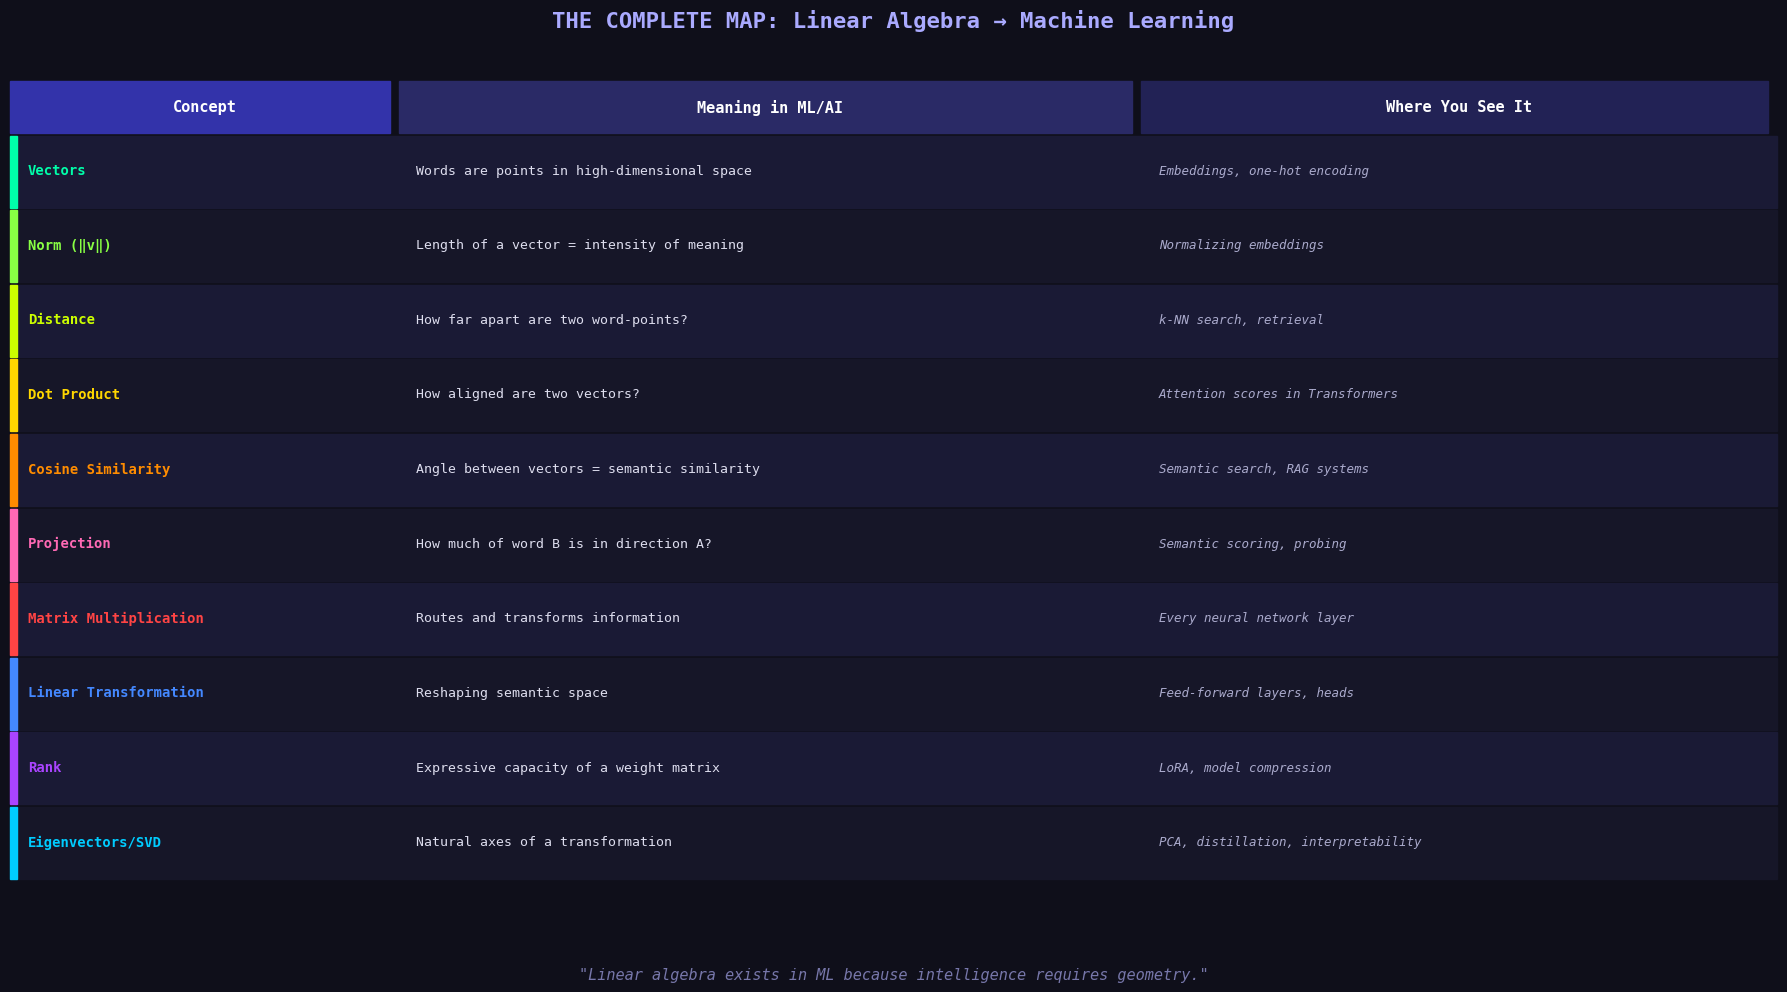


  WHAT COMES NEXT

  Calculus     → How geometry MOVES (gradients = directions to improve)
  Probability  → Uncertainty IN geometry (distributions over word space)
  Attention    → Dot product × softmax × matrix multiply (Transformers!)

  You did not just study linear algebra.
  You reverse-engineered how intelligence works.


In [50]:
summary = [
    ('Vectors',              'Words are points in high-dimensional space',
     'Embeddings, one-hot encoding'),
    ('Norm (‖v‖)',           'Length of a vector = intensity of meaning',
     'Normalizing embeddings'),
    ('Distance',             'How far apart are two word-points?',
     'k-NN search, retrieval'),
    ('Dot Product',          'How aligned are two vectors?',
     'Attention scores in Transformers'),
    ('Cosine Similarity',    'Angle between vectors = semantic similarity',
     'Semantic search, RAG systems'),
    ('Projection',           'How much of word B is in direction A?',
     'Semantic scoring, probing'),
    ('Matrix Multiplication','Routes and transforms information',
     'Every neural network layer'),
    ('Linear Transformation','Reshaping semantic space',
     'Feed-forward layers, heads'),
    ('Rank',                 'Expressive capacity of a weight matrix',
     'LoRA, model compression'),
    ('Eigenvectors/SVD',     'Natural axes of a transformation',
     'PCA, distillation, interpretability'),
]

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')
ax.axis('off')
ax.set_title('THE COMPLETE MAP: Linear Algebra → Machine Learning',
             fontsize=16, fontweight='bold', color='#aaaaff',
             pad=20, y=1.02)

# Table header
headers = ['Concept', 'Meaning in ML/AI', 'Where You See It']
col_widths = [0.22, 0.42, 0.36]
col_xs = [0.0, 0.22, 0.64]
header_colors = ['#3333aa', '#2a2a66', '#222255']

for hx, hw, h, hc in zip(col_xs, col_widths, headers, header_colors):
    rect = plt.Rectangle((hx, 0.93), hw - 0.005, 0.06,
                          color=hc, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(hx + hw/2, 0.96, h, transform=ax.transAxes,
            ha='center', va='center', color='white',
            fontsize=11, fontweight='bold')

# Row colors alternate
row_colors = ['#1a1a35', '#161628']
accent_colors = [
    '#00FFAA', '#88FF44', '#CCFF00', '#FFD700', '#FF8C00',
    '#FF69B4', '#FF4444', '#4488FF', '#AA44FF', '#00CCFF'
]

n_rows = len(summary)
row_h = 0.86 / n_rows

for i, (concept, meaning, usage) in enumerate(summary):
    y = 0.93 - (i + 1) * row_h
    rc = row_colors[i % 2]
    ac = accent_colors[i]

    # Row background
    rect = plt.Rectangle((0, y), 1.0, row_h - 0.003,
                          color=rc, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)

    # Concept (colored)
    ax.text(col_xs[0] + 0.01, y + row_h/2, concept,
            transform=ax.transAxes, ha='left', va='center',
            color=ac, fontsize=10, fontweight='bold', fontfamily='monospace')

    # Meaning
    ax.text(col_xs[1] + 0.01, y + row_h/2, meaning,
            transform=ax.transAxes, ha='left', va='center',
            color='#ddddee', fontsize=9.5)

    # Usage
    ax.text(col_xs[2] + 0.01, y + row_h/2, usage,
            transform=ax.transAxes, ha='left', va='center',
            color='#aaaacc', fontsize=9, style='italic')

    # Left accent bar
    rect2 = plt.Rectangle((0, y), 0.004, row_h - 0.003,
                           color=ac, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect2)

# Footer quote
ax.text(0.5, -0.04,
        '"Linear algebra exists in ML because intelligence requires geometry."',
        transform=ax.transAxes, ha='center', va='center',
        color='#7777aa', fontsize=11, style='italic')

plt.tight_layout()
plt.savefig('final_summary.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

print()
print('=' * 70)
print('  WHAT COMES NEXT')
print('=' * 70)
print()
print('  Calculus     → How geometry MOVES (gradients = directions to improve)')
print('  Probability  → Uncertainty IN geometry (distributions over word space)')
print('  Attention    → Dot product × softmax × matrix multiply (Transformers!)')
print()
print('  You did not just study linear algebra.')
print('  You reverse-engineered how intelligence works.')
print('=' * 70)